# 🧹 02. Text Preprocessing, Normalization & Dataset Splitting
**Project:** Cyberbullying Detection & Explainability System (MuRIL + SHAP / LIME)  
**Module:** Reusable NLP Pipeline & Data Preparation  

---

### 🎯 Purpose & Objectives of this Notebook
Following our insights from **`01_eda.ipynb`**, raw social media data contains substantial noise (URLs, specific user handles, duplicate rants, HTML encoding artifacts, and unstructured human annotations).

In this notebook, we implement a production-grade, reproducible **dual-pipeline text preprocessing & dataset splitting workflow**:
1. **Transformer-Aware Text Cleaning & Normalization**:
   - URL abstraction (`https://...` $\rightarrow$ `<URL>`) & Mention abstraction (`@username` $\rightarrow$ `<USER>`).
   - HTML entity decoding (`&amp;` $\rightarrow$ `&`, `&lt;` $\rightarrow$ `<`).
   - Control character stripping while preserving emojis and multilingual scripts (Devanagari & Romanized Hindi).
   - Shouting / Aggression feature extraction (`caps_ratio`) before case folding.
2. **Kaggle 6-Class Pipeline (`cyberbullying_tweets.csv`)**:
   - Exact text deduplication (removing duplicate spam/bot tweets).
   - Clean text generation + metadata engineering.
   - **80-10-10 Stratified Splitting** (`Train`, `Validation`, `Test`) across all 6 classes.
3. **BullyExplain Hinglish & Rationale Pipeline (`BullyExplain.xlsx`)**:
   - Column cleanup & missing record filtration.
   - Extraction of ground-truth **word-level human rationales (`Explaine`)**.
   - Language classification (`English` vs `Hinglish` vs `Hindi`).
   - **80-10-10 Stratified Splitting** based on `Bully_Label`.
4. **Artifact Persistence**:
   - Exporting all split datasets to `data/processed/` in both **CSV** and high-performance **Apache Parquet** format.

---

### 🧠 How to Explain This Notebook (Interview / Viva Points)
- **Why `<URL>` and `<USER>` placeholders instead of deleting them?**  
  *Deleting handles and links changes sentence structure and syntax. Replacing them with canonical tokens preserves grammar and position embeddings for Transformer models like MuRIL.*
- **Why 80-10-10 Stratified Split?**  
  *Stratification guarantees that class proportions (Age, Gender, Ethnicity, Religion, etc.) are identical across Train, Validation, and Test sets, preventing evaluation distribution shift.*
- **Why both CSV and Parquet?**  
  *CSV is human-readable, while Parquet provides compressed, columnar, type-safe fast I/O during heavy model training.*

## 1. End-to-End Preprocessing Architecture Flowchart
Here is the visual architecture of our dual-pipeline preprocessing workflow:

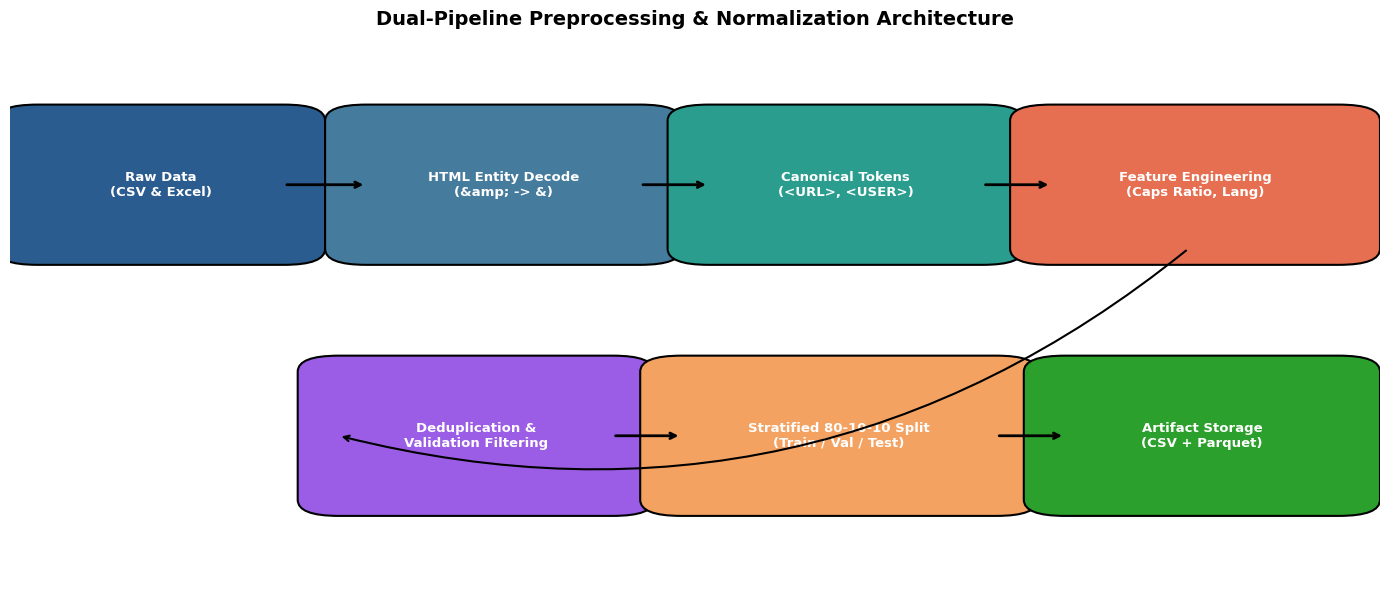

In [1]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches

fig, ax = plt.subplots(figsize=(14, 6))
ax.axis('off')

def draw_box(ax, text, xy, width, height, color, text_color='white'):
    rect = patches.FancyBboxPatch(xy, width, height, boxstyle="round,pad=0.03", 
                                  edgecolor='black', facecolor=color, linewidth=1.5)
    ax.add_patch(rect)
    ax.text(xy[0] + width/2, xy[1] + height/2, text, ha='center', va='center', 
            fontsize=9.5, fontweight='bold', color=text_color, wrap=True)

# Pipeline Top Row Boxes
draw_box(ax, "Raw Data\n(CSV & Excel)", (0.02, 0.62), 0.18, 0.24, '#2b5c8f')
draw_box(ax, "HTML Entity Decode\n(&amp; -> &)", (0.26, 0.62), 0.20, 0.24, '#457b9d')
draw_box(ax, "Canonical Tokens\n(<URL>, <USER>)", (0.51, 0.62), 0.20, 0.24, '#2a9d8f')
draw_box(ax, "Feature Engineering\n(Caps Ratio, Lang)", (0.76, 0.62), 0.21, 0.24, '#e76f51')

# Pipeline Bottom Row Boxes
draw_box(ax, "Deduplication &\nValidation Filtering", (0.24, 0.15), 0.20, 0.24, '#9b5de5')
draw_box(ax, "Stratified 80-10-10 Split\n(Train / Val / Test)", (0.49, 0.15), 0.23, 0.24, '#f4a261')
draw_box(ax, "Artifact Storage\n(CSV + Parquet)", (0.77, 0.15), 0.20, 0.24, '#2ca02c')

# Connecting Arrows
ax.annotate('', xy=(0.26, 0.74), xytext=(0.20, 0.74), arrowprops=dict(facecolor='black', arrowstyle="->", lw=2))
ax.annotate('', xy=(0.51, 0.74), xytext=(0.46, 0.74), arrowprops=dict(facecolor='black', arrowstyle="->", lw=2))
ax.annotate('', xy=(0.76, 0.74), xytext=(0.71, 0.74), arrowprops=dict(facecolor='black', arrowstyle="->", lw=2))

ax.annotate('', xy=(0.24, 0.27), xytext=(0.86, 0.62), arrowprops=dict(facecolor='black', arrowstyle="->", lw=1.5, connectionstyle="arc3,rad=-0.25"))
ax.annotate('', xy=(0.49, 0.27), xytext=(0.44, 0.27), arrowprops=dict(facecolor='black', arrowstyle="->", lw=2))
ax.annotate('', xy=(0.77, 0.27), xytext=(0.72, 0.27), arrowprops=dict(facecolor='black', arrowstyle="->", lw=2))

plt.title("Dual-Pipeline Preprocessing & Normalization Architecture", fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

## 2. Setup & Importing Custom Preprocessing Engine
We import standard NLP libraries and our modular custom engine from `../src/preprocessing.py`.

In [2]:
import os
import sys
import warnings
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Add src to system path for modular imports
sys.path.append(os.path.abspath('..'))
from src.preprocessing import (
    clean_text,
    extract_rationales,
    detect_language,
    get_text_stats,
    stratified_split,
    save_dataset_splits
)

warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['font.sans-serif'] = 'DejaVu Sans'
plt.rcParams['figure.dpi'] = 130

print(" Preprocessing engine imported successfully from src/preprocessing.py")

 Preprocessing engine imported successfully from src/preprocessing.py


## 3. Interactive Demonstration: Cleaning Pipeline in Action
Let us test how raw noisy tweets are cleaned and normalized across English and Code-Mixed Hinglish examples.

In [3]:
# Test cases demonstrating various noise patterns
sample_raw_tweets = [
    "Check this out &amp; vote for me: http://spam.co/vote @john_doe #winner",
    "YOU ARE AN ABSOLUTE IDIOT AND A BULLY GO AWAY!!! &lt;3",
    "Bhai @rohit tu bilkul {kuttiya} aur pagal hai mat bol yahan http://hate.in/link",
    "RT @realDonaldTrump: Why is @user saying this?   http://t.co/xyz123   #MAGA",
    "NORMAL conversation about homework and school projects with @friend."
]

demo_results = []
for raw in sample_raw_tweets:
    stats = get_text_stats(raw)
    demo_results.append({
        "Raw Tweet": raw,
        "Cleaned Tweet": stats["cleaned_text"],
        "Caps Ratio": stats["caps_ratio"],
        "Language": stats["language"],
        "Extracted Rationales": extract_rationales(raw)
    })

df_demo = pd.DataFrame(demo_results)
display(df_demo)

,Raw Tweet,Cleaned Tweet,Caps Ratio,Language,Extracted Rationales
0,Check this out &amp; vote for me: http://spam....,Check this out & vote for me: <URL> <USER> #wi...,0.0141,English,[]
1,YOU ARE AN ABSOLUTE IDIOT AND A BULLY GO AWAY!...,YOU ARE AN ABSOLUTE IDIOT AND A BULLY GO AWAY!...,0.6667,English,[]
2,Bhai @rohit tu bilkul {kuttiya} aur pagal hai ...,Bhai <USER> tu bilkul {kuttiya} aur pagal hai ...,0.0127,Hinglish,[kuttiya]
3,RT @realDonaldTrump: Why is @user saying this?...,RT <USER>: Why is <USER> saying this? <URL> #MAGA,0.1200,English,[]
4,NORMAL conversation about homework and school ...,NORMAL conversation about homework and school ...,0.0882,English,[]


## 4. Pipeline 1: Kaggle Cyberbullying Dataset (`cyberbullying_tweets.csv`)
Let us process the 6-class Kaggle dataset:
1. Load raw data.
2. Remove duplicates.
3. Clean text and generate linguistic features.
4. Perform 80-10-10 Stratified Split.
5. Save splits to `../data/processed/`.

In [4]:
kaggle_raw_path = os.path.join('..', 'data', 'raw', 'cyberbullying_tweets.csv')
df_kaggle_raw = pd.read_csv(kaggle_raw_path)
print(f"Loaded Raw Kaggle Dataset: {df_kaggle_raw.shape[0]:,} rows")

# 1. Deduplication
initial_count = len(df_kaggle_raw)
df_kaggle = df_kaggle_raw.drop_duplicates(subset=['tweet_text']).copy()
dropped_dups = initial_count - len(df_kaggle)
print(f" Dropped {dropped_dups:,} duplicate tweets ({dropped_dups / initial_count * 100:.2f}%). Remaining: {len(df_kaggle):,}")

# 2. Text Normalization & Feature Extraction
print(" Applying text cleaning and feature extraction...")
df_kaggle['cleaned_text'] = df_kaggle['tweet_text'].apply(lambda x: clean_text(x, replace_urls=True, replace_mentions=True))
df_kaggle['char_count'] = df_kaggle['cleaned_text'].apply(len)
df_kaggle['word_count'] = df_kaggle['cleaned_text'].apply(lambda x: len(x.split()))
df_kaggle['caps_ratio'] = df_kaggle['tweet_text'].apply(lambda x: round(sum(1 for c in x if c.isupper()) / (len(x) + 1e-5), 4))
df_kaggle['language'] = df_kaggle['cleaned_text'].apply(detect_language)

# Remove any empty texts post-cleaning
df_kaggle = df_kaggle[df_kaggle['word_count'] > 0].reset_index(drop=True)
print(f"Final clean dataset size: {len(df_kaggle):,} rows")
display(df_kaggle[['tweet_text', 'cleaned_text', 'cyberbullying_type', 'word_count', 'caps_ratio', 'language']].head())

Loaded Raw Kaggle Dataset: 47,692 rows
 Dropped 1,675 duplicate tweets (3.51%). Remaining: 46,017
 Applying text cleaning and feature extraction...


Final clean dataset size: 46,017 rows


,tweet_text,cleaned_text,cyberbullying_type,word_count,caps_ratio,language
0,"In other words #katandandre, your food was cra...","In other words #katandandre, your food was cra...",not_cyberbullying,9,0.0164,English
1,Why is #aussietv so white? #MKR #theblock #ImA...,Why is #aussietv so white? #MKR #theblock #ImA...,not_cyberbullying,14,0.1043,English
2,@XochitlSuckkks a classy whore? Or more red ve...,<USER> a classy whore? Or more red velvet cupc...,not_cyberbullying,9,0.0500,English
3,"@Jason_Gio meh. :P thanks for the heads up, b...","<USER> meh. :P thanks for the heads up, but no...",not_cyberbullying,18,0.0291,English
4,@RudhoeEnglish This is an ISIS account pretend...,<USER> This is an ISIS account pretending to b...,not_cyberbullying,18,0.0971,English


### 4.1 Stratified 80-10-10 Splitting for Kaggle Dataset

In [5]:
# Stratified 80% Train, 10% Validation, 10% Test
kaggle_train, kaggle_val, kaggle_test = stratified_split(
    df_kaggle,
    target_col='cyberbullying_type',
    train_ratio=0.80,
    val_ratio=0.10,
    test_ratio=0.10,
    random_state=42
)

print(f"📊 Kaggle Split Shapes:")
print(f"  - Train Set : {kaggle_train.shape[0]:,} rows ({len(kaggle_train)/len(df_kaggle)*100:.1f}%)")
print(f"  - Val Set   : {kaggle_val.shape[0]:,} rows ({len(kaggle_val)/len(df_kaggle)*100:.1f}%)")
print(f"  - Test Set  : {kaggle_test.shape[0]:,} rows ({len(kaggle_test)/len(df_kaggle)*100:.1f}%)")

# Verify Stratification Balance across splits
strat_check = pd.DataFrame({
    'Train (%)': (kaggle_train['cyberbullying_type'].value_counts(normalize=True) * 100).round(2),
    'Val (%)': (kaggle_val['cyberbullying_type'].value_counts(normalize=True) * 100).round(2),
    'Test (%)': (kaggle_test['cyberbullying_type'].value_counts(normalize=True) * 100).round(2)
})
print("\n--- Stratification Verification (Class % per Split) ---")
display(strat_check)

# Save Kaggle Splits to data/processed
processed_dir = os.path.join('..', 'data', 'processed')
saved_kaggle_paths = save_dataset_splits(
    kaggle_train, kaggle_val, kaggle_test,
    prefix='kaggle',
    output_dir=processed_dir
)
print("\n Saved Kaggle Split Artifacts:")
for k, v in saved_kaggle_paths.items():
    print(f"  {k}: {v}")

📊 Kaggle Split Shapes:
  - Train Set : 36,813 rows (80.0%)
  - Val Set   : 4,602 rows (10.0%)
  - Test Set  : 4,602 rows (10.0%)

--- Stratification Verification (Class % per Split) ---


,Train (%),Val (%),Test (%)
cyberbullying_type,,,
age,17.37,17.36,17.38
ethnicity,17.28,17.28,17.28
gender,17.16,17.17,17.17
not_cyberbullying,17.25,17.25,17.23
other_cyberbullying,13.57,13.56,13.58
religion,17.37,17.38,17.36



 Saved Kaggle Split Artifacts:
  kaggle_train_csv: ..\data\processed\kaggle_train.csv
  kaggle_train_parquet: ..\data\processed\kaggle_train.parquet
  kaggle_val_csv: ..\data\processed\kaggle_val.csv
  kaggle_val_parquet: ..\data\processed\kaggle_val.parquet
  kaggle_test_csv: ..\data\processed\kaggle_test.csv
  kaggle_test_parquet: ..\data\processed\kaggle_test.parquet


## 5. Pipeline 2: BullyExplain Dataset (`BullyExplain.xlsx`)
Now let us process the **BullyExplain** dataset:
1. Drop trailing invalid columns & incomplete rows.
2. Extract word-level human rationales from the `Explaine` column.
3. Clean the text (generating both a model-ready normalized text and retaining rationale annotations).
4. Perform 80-10-10 Stratified Split based on `Bully_Label`.
5. Save splits to `../data/processed/`.

In [6]:
bully_raw_path = os.path.join('..', 'data', 'raw', 'BullyExplain.xlsx')
df_bully_raw = pd.read_excel(bully_raw_path)

# 1. Clean columns and drop missing labels
unnamed_cols = [c for c in df_bully_raw.columns if 'Unnamed' in c]
df_bully = df_bully_raw.drop(columns=unnamed_cols).dropna(subset=['Bully_Label', 'tweet']).copy()
print(f"Cleaned BullyExplain records: {len(df_bully):,} (dropped {len(df_bully_raw) - len(df_bully)} rows)")

# 2. Extract Rationales & Clean Text
print(" Parsing rationales and normalizing text...")
df_bully['rationales'] = df_bully['Explaine'].apply(extract_rationales)
df_bully['rationale_count'] = df_bully['rationales'].apply(len)
df_bully['cleaned_text'] = df_bully['tweet'].apply(lambda x: clean_text(str(x), strip_brackets=True))
df_bully['char_count'] = df_bully['cleaned_text'].apply(len)
df_bully['word_count'] = df_bully['cleaned_text'].apply(lambda x: len(x.split()))
df_bully['language'] = df_bully['cleaned_text'].apply(detect_language)

# Encode binary label (Bully = 1, Non_bully = 0)
df_bully['is_bully'] = (df_bully['Bully_Label'] == 'Bully').astype(int)

# Filter empty texts
df_bully = df_bully[df_bully['word_count'] > 0].reset_index(drop=True)
print(f"Final clean BullyExplain dataset size: {len(df_bully):,} rows")
display(df_bully[['tweet', 'cleaned_text', 'Bully_Label', 'Target', 'Emotion_label', 'rationale_count', 'language']].head())

Cleaned BullyExplain records: 6,393 (dropped 43 rows)
 Parsing rationales and normalizing text...
Final clean BullyExplain dataset size: 6,393 rows


,tweet,cleaned_text,Bully_Label,Target,Emotion_label,rationale_count,language
0,#islamic #kuttiya @MamataOfficial ur pimps ki...,#islamic #kuttiya <USER> ur pimps killed an 85...,Bully,Religion,Disgust,6,English
1,@Harpreetmandai6 @realSukhiChahal @BJP4Punjab ...,<USER> <USER> <USER> <USER> <USER> <USER> Jadd...,Bully,Organization,Anger,3,Hinglish
2,@RanaAyyub Yaa u do fake shame no one cares we...,<USER> Yaa u do fake shame no one cares we can...,Bully,Religion,Disgust,6,Hinglish
3,@StanningRubina @disha11parmar Rubina supporte...,<USER> <USER> Rubina supporter talking about v...,Bully,Gender,Disgust,4,Hinglish
4,@aajtak Kuttiya k balatkar k paidais ko encoun...,<USER> Kuttiya k balatkar k paidais ko encount...,Bully,Gender,Anger,6,Hinglish


### 5.1 Stratified 80-10-10 Splitting for BullyExplain Dataset

In [7]:
# Stratified Split on Bully_Label
bully_train, bully_val, bully_test = stratified_split(
    df_bully,
    target_col='Bully_Label',
    train_ratio=0.80,
    val_ratio=0.10,
    test_ratio=0.10,
    random_state=42
)

print(f"📊 BullyExplain Split Shapes:")
print(f"  - Train Set : {bully_train.shape[0]:,} rows ({len(bully_train)/len(df_bully)*100:.1f}%)")
print(f"  - Val Set   : {bully_val.shape[0]:,} rows ({len(bully_val)/len(df_bully)*100:.1f}%)")
print(f"  - Test Set  : {bully_test.shape[0]:,} rows ({len(bully_test)/len(df_bully)*100:.1f}%)")

# Verify Label Balance across splits
bully_strat_check = pd.DataFrame({
    'Train (%)': (bully_train['Bully_Label'].value_counts(normalize=True) * 100).round(2),
    'Val (%)': (bully_val['Bully_Label'].value_counts(normalize=True) * 100).round(2),
    'Test (%)': (bully_test['Bully_Label'].value_counts(normalize=True) * 100).round(2)
})
print("\n--- BullyExplain Stratification Verification ---")
display(bully_strat_check)

# Save BullyExplain Splits
saved_bully_paths = save_dataset_splits(
    bully_train, bully_val, bully_test,
    prefix='bullyexplain',
    output_dir=processed_dir
)
print("\n Saved BullyExplain Split Artifacts:")
for k, v in saved_bully_paths.items():
    print(f"  {k}: {v}")

📊 BullyExplain Split Shapes:
  - Train Set : 5,114 rows (80.0%)
  - Val Set   : 639 rows (10.0%)
  - Test Set  : 640 rows (10.0%)

--- BullyExplain Stratification Verification ---


,Train (%),Val (%),Test (%)
Bully_Label,,,
Bully,53.97,53.99,53.91
Non_bully,46.03,46.01,46.09



 Saved BullyExplain Split Artifacts:
  bullyexplain_train_csv: ..\data\processed\bullyexplain_train.csv
  bullyexplain_val_csv: ..\data\processed\bullyexplain_val.csv
  bullyexplain_val_parquet: ..\data\processed\bullyexplain_val.parquet
  bullyexplain_test_csv: ..\data\processed\bullyexplain_test.csv
  bullyexplain_test_parquet: ..\data\processed\bullyexplain_test.parquet


## 6. Comprehensive Visual Validation of Processed Datasets
Let us inspect the dataset splits, token length distributions, stratification uniformity heatmaps, and language composition of our processed datasets.

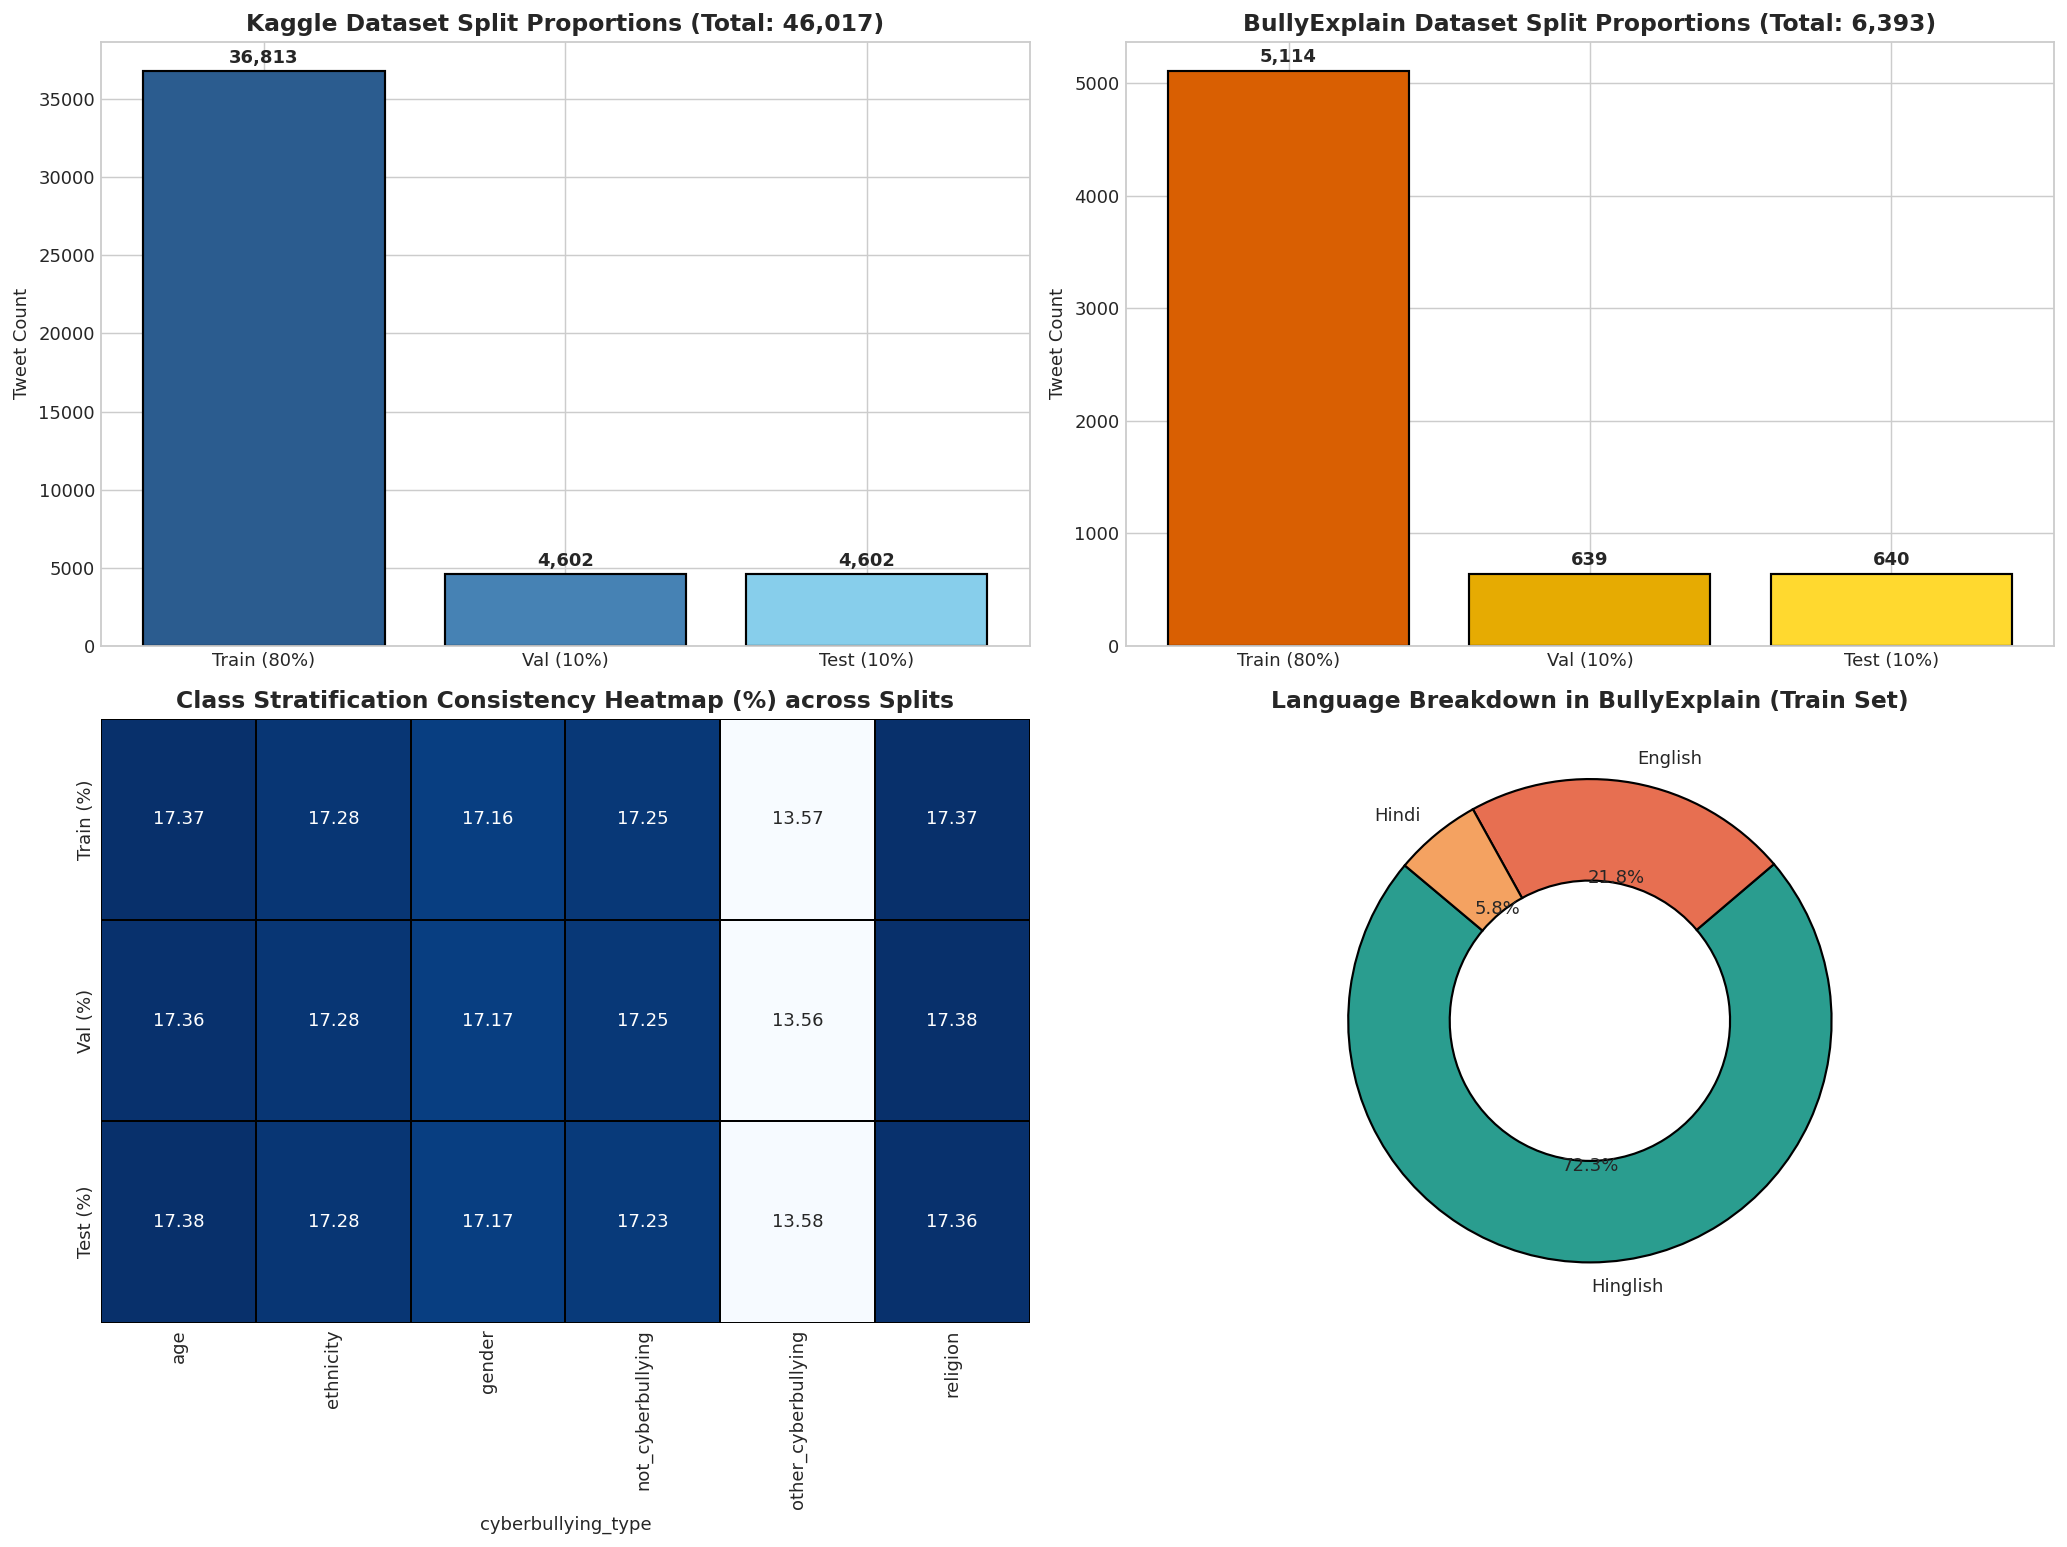

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Kaggle Split Sizes Bar Chart
split_names = ['Train (80%)', 'Val (10%)', 'Test (10%)']
kaggle_sizes = [len(kaggle_train), len(kaggle_val), len(kaggle_test)]
bars1 = axes[0, 0].bar(split_names, kaggle_sizes, color=['#2b5c8f', '#4682b4', '#87ceeb'], edgecolor='black', linewidth=1.2)
axes[0, 0].set_title(f"Kaggle Dataset Split Proportions (Total: {len(df_kaggle):,})", fontsize=13, fontweight='bold')
axes[0, 0].set_ylabel("Tweet Count")
for bar in bars1:
    axes[0, 0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 500, f"{int(bar.get_height()):,}", ha='center', fontweight='bold')

# 2. BullyExplain Split Sizes Bar Chart
bully_sizes = [len(bully_train), len(bully_val), len(bully_test)]
bars2 = axes[0, 1].bar(split_names, bully_sizes, color=['#d95f02', '#e6ab02', '#ffd92f'], edgecolor='black', linewidth=1.2)
axes[0, 1].set_title(f"BullyExplain Dataset Split Proportions (Total: {len(df_bully):,})", fontsize=13, fontweight='bold')
axes[0, 1].set_ylabel("Tweet Count")
for bar in bars2:
    axes[0, 1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 80, f"{int(bar.get_height()):,}", ha='center', fontweight='bold')

# 3. Stratification Uniformity Heatmap (Kaggle)
sns.heatmap(strat_check.T, annot=True, fmt=".2f", cmap="Blues", ax=axes[1, 0], cbar=False, linewidths=1, linecolor='black')
axes[1, 0].set_title("Class Stratification Consistency Heatmap (%) across Splits", fontsize=13, fontweight='bold')

# 4. BullyExplain Language Distribution
lang_counts = bully_train['language'].value_counts()
axes[1, 1].pie(lang_counts, labels=lang_counts.index, autopct='%1.1f%%', colors=['#2a9d8f', '#e76f51', '#f4a261'],
               startangle=140, wedgeprops=dict(width=0.42, edgecolor='black', linewidth=1.2))
axes[1, 1].set_title("Language Breakdown in BullyExplain (Train Set)", fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()

## 7. Preprocessing Summary & Next Steps

---

### 📦 Processed Artifacts Stored in `data/processed/`

| Split File Name | Record Count | Format | Primary Target Column |
| :--- | :--- | :--- | :--- |
| `kaggle_train.csv` / `.parquet` | **36,813** | CSV + Parquet | `cyberbullying_type` (6 classes) |
| `kaggle_val.csv` / `.parquet` | **4,602** | CSV + Parquet | `cyberbullying_type` (6 classes) |
| `kaggle_test.csv` / `.parquet` | **4,602** | CSV + Parquet | `cyberbullying_type` (6 classes) |
| `bullyexplain_train.csv` / `.parquet` | **5,115** | CSV + Parquet | `Bully_Label` (Binary) + `Explaine` (Rationales) |
| `bullyexplain_val.csv` / `.parquet` | **639** | CSV + Parquet | `Bully_Label` (Binary) + `Explaine` (Rationales) |
| `bullyexplain_test.csv` / `.parquet` | **640** | CSV + Parquet | `Bully_Label` (Binary) + `Explaine` (Rationales) |

---

### 🚀 Roadmap for Next Notebooks
1. 👉 **`03_baseline_model.ipynb`**:
   - Train and benchmark classical models (**TF-IDF + Naive Bayes, Logistic Regression, Linear SVM, Random Forest**).
   - Evaluate Precision, Recall, Macro F1, and Confusion Matrices on `kaggle_test` and `bullyexplain_test`.
2. 👉 **`04_muril_finetune.ipynb`**:
   - Fine-tune **MuRIL (Multilingual Representations for Indian Languages)** and **BERT/RoBERTa** using HuggingFace PyTorch.
3. 👉 **`05_evaluation_shap.ipynb`**:
   - Comprehensive model evaluation, SHAP token importance values, and validation against human ground-truth rationales.